In [1]:
import pandas as pd

In [2]:
# E:\\docs\\book_reviews\\manning\\solve_any_data_analysis_problem\\notebooks\\

survey = pd.read_parquet("E:\\docs\\book_reviews\\manning\\solve_any_data_analysis_problem\\notebooks\\survey.parquet.gz")

survey_ai_users = pd.read_parquet("E:\\docs\\book_reviews\\manning\\solve_any_data_analysis_problem\\notebooks\\survey_ai_users.parquet.gz")
 
survey_ai_users["YearsCodePro"].unique()

array(['9', '4', '21', '3', '15', None, 'Less than 1 year', '10', '2',
       '6', '14', '7', '5', '16', '20', '11', '12', '19', '8', '50', '27',
       '13', '1', '18', '44', '22', '25', '24', '17', '26', '37', '30',
       'More than 50 years', '23', '32', '39', '28', '35', '36', '33',
       '34', '41', '31', '40', '38', '29', '43', '42', '45', '48', '47',
       '49', '46'], dtype=object)

In [3]:
# This column should be numeric but is actually stored as text because of those two values: “less than 1 year” and “more than 50 years”. 
# Since the rest of the values are not binned, we should make this column numeric. We can replace those two text values with 0 and 50, 
# respectively, without compromising the data too much.

survey_ai_users["YearsCodePro"] = (
    survey_ai_users["YearsCodePro"]
    .replace({
        'Less than 1 year': 0,
        'More than 50 years': 50
    })
    .astype(float) # to account for NULLs
)

<Axes: >

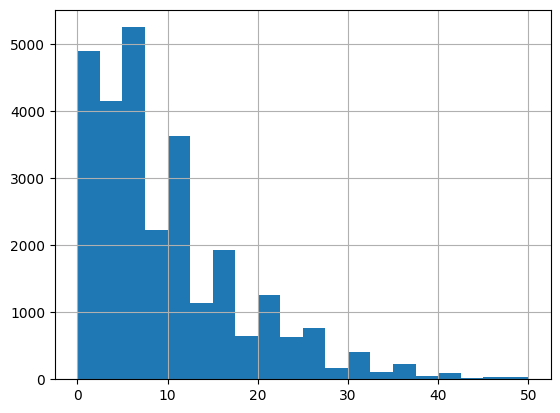

In [4]:
# Now that we have a numeric “years of experience” column, let’s observe its distribution. 

survey_ai_users["YearsCodePro"].hist(bins=20)

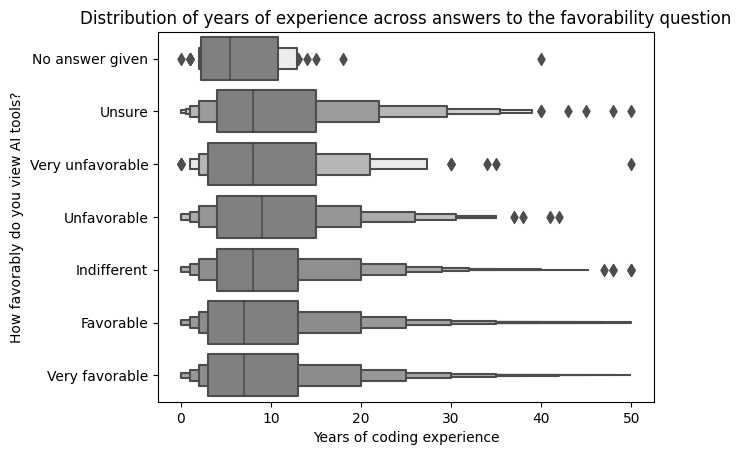

In [7]:
# boxenplots

import seaborn as sns
import matplotlib.pyplot as plt  

fig, axis = plt.subplots()
 
sns.boxenplot(
    data=survey_ai_users,
    x="YearsCodePro", y="AISent",
    color="gray",
    ax=axis
)
 
axis.set(
    title="Distribution of years of experience across answers to the favorability question",
    xlabel="Years of coding experience",
    ylabel="How favorably do you view AI tools?"
)
 
plt.show()

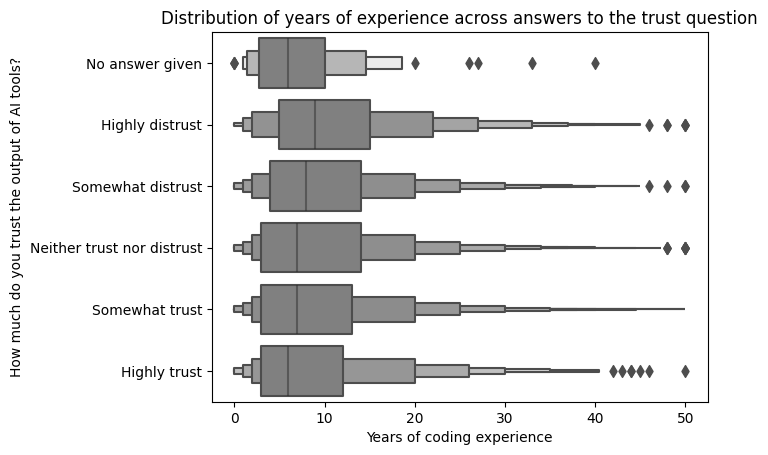

In [9]:
# look at how much different experience levels trust the output of AI tools.

fig, axis = plt.subplots()
 
sns.boxenplot(
    data=survey_ai_users,
    x="YearsCodePro", y="AIBen",
    color="gray",
    ax=axis
)
 
axis.set(
    title="Distribution of years of experience across answers to the trust question",
    xlabel="Years of coding experience",
    ylabel="How much do you trust the output of AI tools?"
)
 
plt.show()

In [10]:
# “years of experience” represent as a categorical value. - Binning continuous values to discrete categories

exp_bins = pd.cut(survey_ai_users["YearsCodePro"],
                  bins=[-1, 0, 2, 5, 10, 20, 50],
                  labels=["0", "1-2 years", "3-5 years",
                          "6-10 years", "11-20 years",
                          "over 20 years"]
                 )
 
# verify the groups
survey_ai_users.groupby(exp_bins)["YearsCodePro"].agg(["min", "max"])

,min,max
YearsCodePro,,
0,0.0,0.0
1-2 years,1.0,2.0
3-5 years,3.0,5.0
6-10 years,6.0,10.0
11-20 years,11.0,20.0
over 20 years,21.0,50.0


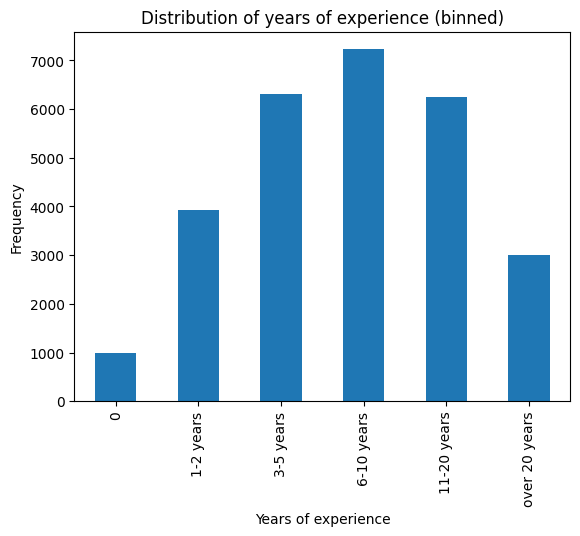

In [11]:
fig, axis = plt.subplots()
 
(
    exp_bins
    .value_counts()
    .sort_index()
    .plot
    .bar(ax=axis)
)
 
axis.set(
    title="Distribution of years of experience (binned)",
    xlabel="Years of experience",
    ylabel="Frequency"
)
 
plt.show()

In [12]:
exp_vs_sent = pd.crosstab(
    index=exp_bins,
    columns=survey_ai_users["AISent"],
    normalize="index"
)
 
exp_vs_sent

AISent,No answer given,Unsure,Very unfavorable,Unfavorable,Indifferent,Favorable,Very favorable
YearsCodePro,,,,,,,
0,0.001011,0.015167,0.004044,0.018200,0.104146,0.505561,0.351871
1-2 years,0.002552,0.017096,0.004083,0.015310,0.101046,0.510079,0.349834
3-5 years,0.001587,0.014596,0.001745,0.015865,0.104871,0.488974,0.372362
6-10 years,0.001384,0.016602,0.004289,0.019231,0.112618,0.476065,0.369812
11-20 years,0.001599,0.017426,0.003197,0.023341,0.112390,0.483933,0.358114
over 20 years,0.000332,0.021920,0.004318,0.020923,0.107938,0.474925,0.369645


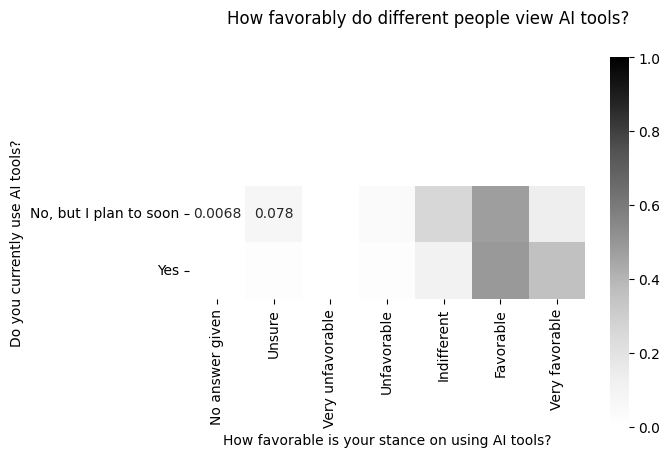

In [14]:
def create_heatmap(data, square=True):
    fig, axis = plt.subplots()
 
    sns.heatmap(
        data=data,
        cmap="Greys",
        vmin=0,
        vmax=1,
        square=square,
        annot=True,
        ax=axis
    )
 
    return fig, axis
 
fig, axis = create_heatmap(
    pd.crosstab(
        index=survey.loc[survey["AISelect"] != "No, and I don't plan to", "AISelect"],
        columns=survey.loc[survey["AISelect"] != "No, and I don't plan to", "AISent"],
        normalize="index"
    )
)
 
fig.suptitle("How favorably do different people view AI tools?")
 
axis.set(
    xlabel="How favorable is your stance on using AI tools?",
    ylabel="Do you currently use AI tools?"
)
 
plt.show()

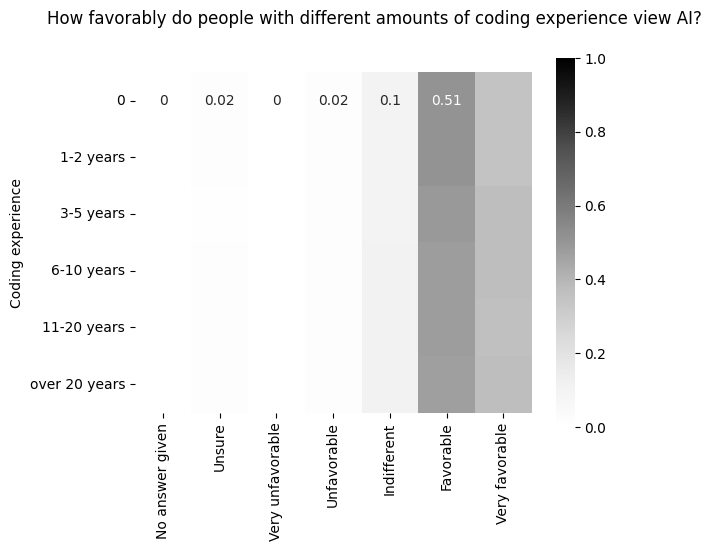

In [15]:
fig, axis = create_heatmap(
    exp_vs_sent.round(2)
)
 
fig.suptitle("How favorably do people with different amounts of coding experience view AI?")
 
axis.set(
    xlabel=None,
    ylabel="Coding experience"
)
 
plt.show()

In [16]:
fig, axis = create_heatmap(
    exp_vs_trust.round(2)
)
 
fig.suptitle("How much do people with different amounts of coding experience trust the output of an AI?")
 
axis.set(
    xlabel=None,
    ylabel="Coding experience"
)
 
plt.show()

NameError: name 'exp_vs_trust' is not defined

In [ ]:
# Where was exp_vs_trust defined?

In [17]:
# irst, we will create the ranking and then calculate the two statistical metrics

trust_exp_data = (
    survey_ai_users
    .dropna(subset=["YearsCodePro", "AIBen"], how="any")
    .loc[survey_ai_users["AIBen"] != "No answer given", :]
)
 
trust_rank = (
    pd.Series(
        trust_exp_data["AIBen"]
        .factorize(sort=True)[0]
    )
    .rank()
)
 
from scipy.stats import spearmanr, kendalltau
 
correlation, p_value = spearmanr(
    trust_exp_data["YearsCodePro"],
    trust_rank
)
 
print("Spearman's\n", correlation, p_value)
 
correlation, p_value = kendalltau(
    trust_exp_data["YearsCodePro"],
    trust_rank
)
 
print("Kendall's tau\n", correlation, p_value)


Spearman's
 -0.0650445414009189 2.6886332522054823e-27
Kendall's tau
 -0.05052236119624125 2.5557806077186822e-27


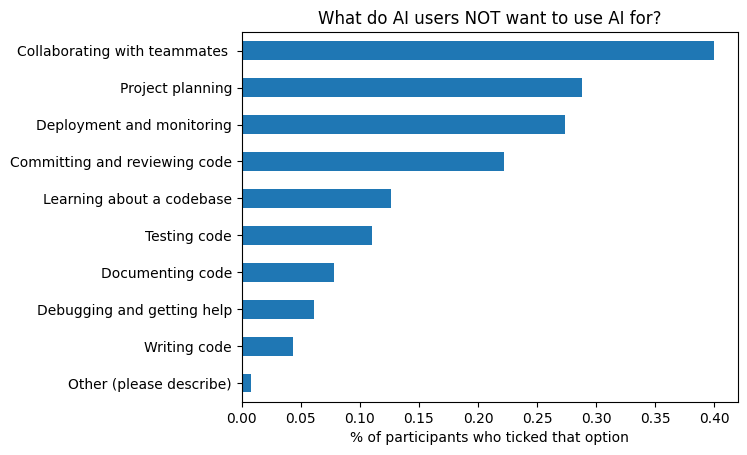

In [18]:
# look at which use cases people are least interested in

ai_not_interested_indicators = (
  survey.loc[survey["AISelect"] == "Yes", "AIToolNot interested in Using"]
  .str.get_dummies(sep=";")
)
 
fig, axis = plt.subplots()
 
(
    ai_not_interested_indicators
    .mean()
    .sort_values()
    .plot
    .barh(ax=axis)
)
 
axis.set(
    title="What do AI users NOT want to use AI for?",
    xlabel="% of participants who ticked that option"
)
 
plt.show()

In [22]:
devtypes = (
    survey_ai_users
    .dropna(subset=["DevType"])
    .query("DevType.str.startswith('Developer')")
    .loc[:,"DevType"]
)
 
devtypes.value_counts()

Developer, full-stack                            12316
Developer, back-end                               5499
Developer, front-end                              2622
Developer, mobile                                 1126
Developer, desktop or enterprise applications     1087
Developer, embedded applications or devices        486
Developer, game or graphics                        326
Developer, QA or test                              231
Developer Experience                               139
Developer Advocate                                  98
Name: DevType, dtype: int64

In [23]:
devtype_map = {}
 
dev_exclusions = ["Developer Experience", "Developer Advocate"]
 
dev_devtypes = [col for col in devtypes.value_counts().index if col not in dev_exclusions]
 
for col in dev_devtypes:
    devtype_map[col] = "Developer"

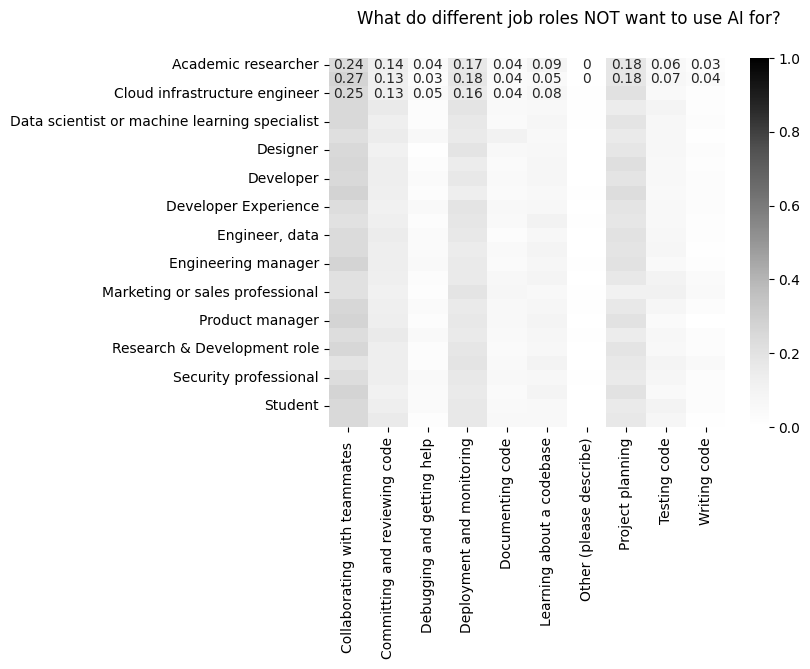

In [24]:
# et’s do our long-form data transformation to arrive at a heatmap to break this last analysis down by job role

ai_users_not_int = (
    pd.concat([survey, ai_not_interested_indicators], axis=1)
    .dropna(subset=ai_not_interested_indicators.columns, how="any")
)
 
ai_users_not_int["job_category"] = ai_users_not_int["DevType"].replace(devtype_map)
 
not_interested_job_dfs = []

# cross-reference AI “anti-” use cases with job categories
for col in ai_not_interested_indicators.columns:
    option_df = (
        ai_users_not_int[ai_users_not_int[col] == 1]
        .dropna(subset="job_category")
        .groupby("job_category")
        .size()
        .reset_index(name="count")
        .assign(option=col)
    )
    not_interested_job_dfs.append(option_df)


not_interested_options_vs_jobs = pd.concat(not_interested_job_dfs,axis=0, ignore_index=True)

# reshape into a crosstab
job_not_int_crosstab = (
    pd.crosstab(index=not_interested_options_vs_jobs["option"],
                columns=not_interested_options_vs_jobs["job_category"],
                values=not_interested_options_vs_jobs["count"],
                aggfunc="sum",
                normalize="columns")
    .transpose()
)

# finally, visualize as a heatmap
fig, axis = create_heatmap(
    job_not_int_crosstab.round(2),
    square=False
)
 
fig.suptitle("What do different job roles NOT want to use AI for?")
 
axis.set(xlabel=None, ylabel=None)
 
plt.show()